## Домашка 2
<h4><em>«Одно Кольцо, чтоб править всеми,<br>
Одно Кольцо, чтоб всех найти,<br>
Одно Кольцо, чтоб собрать всех в тени<br>
И заковать их всех во Тьме»</em><br>
— <em>Властелин колец</em>
</h4>

Эта домашка про приоритизацию метрик. За неё можно получить максимум 12 баллов.

**Дедлайны**   
Мягкий дедлайн: 27.09.2026 23:59 по МСК.   
Жесткий дедлайн: 04.10.2026 23:59 по МСК.

Штраф за сдачу после мягкого дедлайна: –20% от набранного балла.
После жесткого дедлайна работы не принимаются.

**Правила сдачи**  
Задание выполняется самостоятельно, списывания не допускаются. При обнаружении одинаковых работ балл за задание анулируется у всех студентов, вне зависимости от того, кто у кого списал.

**Использование ИИ**

- Использование генеративных моделей для написания кода допустимо при следующих условиях: сгенерированный фрагмент прочитан, адаптирован под условие задачи и данные, вы способны объяснить каждую его строку. Решение, полученное путем передачи модели формулировки задания целиком и прямого копирования ответа в ячейку ноутбука без содержательной переработки, оценивается в 0 баллов за это задание.
- Ответы на текстовые вопросы (описание поведения графика, интерпретация метрики, формулировка гипотез и т.п.) должны быть написаны вами самостоятельно в markdown-ячейках. Использование генеративных моделей для ответа на текстовые вопросы приводит к аннулированию всей работы, а не отдельного задания: интерпретация результатов — главный проверяемый в курсе навык, передача ее ИИ лишает нас возможности оценить, насколько хорошо вы усвоили материал.
- Если генеративная модель использовалась при решении, в конце ноутбука в отдельной markdown-ячейке укажите: номера заданий, при работе над которыми она применялась, использованную модель (с версией) и текст промтов. При обоснованном подозрении на использование ИИ, не отраженное в этом разделе, работа аннулируется целиком независимо от того, к какой части заданий относится подозрение.

#### **Как сдать домашку?**
1. Создайте закрытый репозиторий в личном гитхаб аккаунте для нашего предмета.
2. Пригласите в него своего ассистента — распределение по ассистентам и их гитхаб юзернеймы находятся в ведомости на листочке нашей дисциплины. Это можно сделать в настройках через раздел Collaborators and teams, уровень доступа ассистента должен быть Write.
3. Скачайте этот ноутбук и решите задания (локально или в Google Colab).
4. В репозитории предмета создайте ветку с номером ДЗ (например hw_2). В эту ветку запушьте .ipynb-файл с решением. Создайте pull request и добавьте в него ассистента как Reviewer. В этот же PR можете пушить сколько угодно изменений, будем смотреть на последнюю версию до наступления дедлайна.
5. Ссылку на PR продублируйте в форме сдачи (форма будет доступна на LMS Karpov Courses и в Телеграм-канале курса).

Пункты 1-2 проделываются один раз. Если вы прошли эти шаги при сдаче других домашек, повторять их не нужно, начинайте сразу с пункта 3.

**Внимание**: Если вы работаете в Google Colab, также скачивайте .ipynb файл и публикуйте его в репозитории. Ссылки на Colab к сдаче не принимаются.

Все датасеты, с которыми предлагается работать в домашних заданиях, взяты из открытых источников или сгенерированы. Любые паттерны, найденные вне заданной канвы решения, являются случайными и не несут в себе смысла или инсайта.

[Данные](https://github.com/brezhnevaan/hse_product_metrics_course/releases/download/datasets_for_hw/hw_2_data.zip)

In [ ]:
!wget -q https://github.com/brezhnevaan/hse_product_metrics_course/releases/download/datasets_for_hw/hw_2_data.zip
!unzip -q -o hw_2_data.zip

In [ ]:
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

### Warm up

#### 1. Game dev — 2 балла
У вас есть данные о событиях в мобильной игре. Рассчитайте и визуализируйте:
- User Stickiness — отношение DAU к MAU (MAU рассчитывайте скользящим окном 30 дней для каждой даты только для полного окна)
- ARPDAU
- Paying Share — доля платящих пользователей
- Sessions per User — среднее число сессий на пользователя
- Daily Play Time — среднее время, проводимое пользователем в игре в день (рассчитываем как общее время в приложении)
- Avg Attempts per Session — среднее число попыток на сессию

*Смотрим на подневную динамику

In [ ]:
df_game = pd.read_csv('data/hw_2_gamedev.csv', index_col=0)
df_game.head()

,session_id,user,date,revenue,attempts,session_length_sec
0,24590322,k0xevcHJ,2022-11-02,NaN,2.0,263
1,24590323,fMaLiagr,2022-11-02,NaN,10.0,953
2,24590324,0EXv0Q2V,2022-11-02,NaN,6.0,630
3,24590325,nY32SwuK,2022-11-02,NaN,9.0,1262
4,24590326,3KZkImTN,2022-11-02,NaN,16.0,2871


Описание данных (уникальный ключ session_id)

- session_id — уникальный идентификатор сессии
- user — уникальный идентификатор юзера
- date — дата
- revenue — суммарная выручка на сессию
- attempts — число попыток на сессию
- session_length_sec — длина сессии в секундах

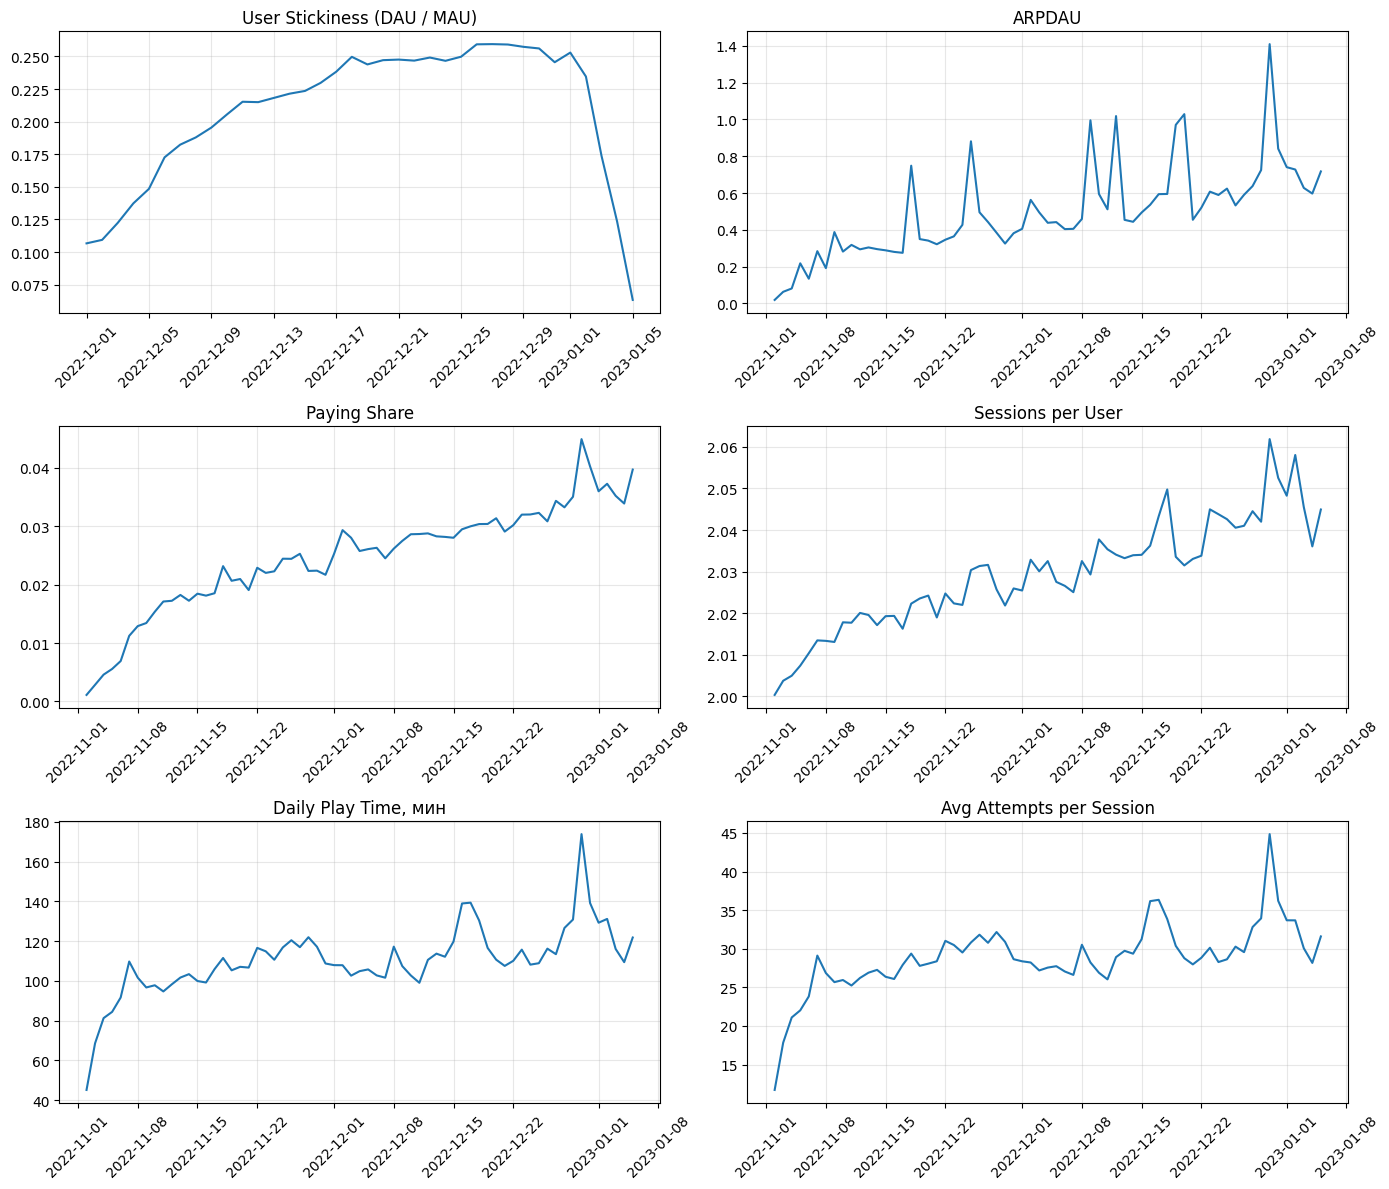

In [ ]:
df_game['date'] = pd.to_datetime(df_game['date'])

# дневные показатели
daily_game = df_game.groupby('date').agg(
    dau=('user', 'nunique'),
    sessions=('session_id', 'count'),
    revenue=('revenue', 'sum'),
    play_time_sec=('session_length_sec', 'sum'),
    avg_attempts=('attempts', 'mean')
)

# число платящих пользователей за день
daily_game['paying_users'] = df_game[df_game['revenue'] > 0].groupby('date')['user'].nunique()
daily_game['paying_users'] = daily_game['paying_users'].fillna(0)

# MAU скользящим окном 30 дней (текущий день + 29 предыдущих), только для полного окна
first_game_date = df_game['date'].min()
mau_list = []
for d in daily_game.index:
    if d - timedelta(days=29) < first_game_date:
        mau_list.append(None)
    else:
        window = df_game[(df_game['date'] >= d - timedelta(days=29)) & (df_game['date'] <= d)]
        mau_list.append(window['user'].nunique())
daily_game['mau'] = mau_list

daily_game['stickiness'] = daily_game['dau'] / daily_game['mau']
daily_game['arpdau'] = daily_game['revenue'] / daily_game['dau']
daily_game['paying_share'] = daily_game['paying_users'] / daily_game['dau']
daily_game['sessions_per_user'] = daily_game['sessions'] / daily_game['dau']
daily_game['play_time_min'] = daily_game['play_time_sec'] / 60 / daily_game['dau']

game_metrics = {
    'stickiness': 'User Stickiness (DAU / MAU)',
    'arpdau': 'ARPDAU',
    'paying_share': 'Paying Share',
    'sessions_per_user': 'Sessions per User',
    'play_time_min': 'Daily Play Time, мин',
    'avg_attempts': 'Avg Attempts per Session'
}

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
for ax, metric in zip(axes.flatten(), game_metrics):
    ax.plot(daily_game.index, daily_game[metric])
    ax.set_title(game_metrics[metric])
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 2. Ride hailing  — 2 балла
У вас есть данные из приложения такси. Рассчитайте и визуализируйте:
- Ride Completion Rate — CR из заказа в завершенную поездку
- Acceptance Rate — доля заказов, принятых водителем (считаем, что приняты все заказы, кроме заказов со статусом 'No Driver Found')
- Cancellation Rate — доля отмененных заказов
- Rides per Driver — среднее число поездок на водителя
- Avg Ride Check — средний чек поездки
- Отношение RTA к ETA (что измеряет эта метрика?)

*Смотрим на подневную динамику

In [ ]:
df_rh = pd.read_csv('data/hw_2_taxi.csv')

In [ ]:
df_rh.head()

,date,time,order_uid,order_status,passenger_id,vehicle_type,pickup_location,drop_location,ETA,RTA,...,reason_for_cancelling_by_customer,cancelled_rides_by_driver,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,fare,ride_distance,driver_ratings,customer_rating,payment_method
0,2024-01-01,00:19:34,2a11faf27f77eae8,Completed,CID8362794,Bike,Udyog Vihar,Ambience Mall,9.0,10.8,...,NaN,NaN,NaN,NaN,NaN,99.0,37.98,4.8,4.8,Cash
1,2024-01-01,01:35:18,33ed1f6bad78bdc8,Completed,CID8300238,Go Mini,Basai Dhankot,Madipur,6.0,8.5,...,NaN,NaN,NaN,NaN,NaN,114.0,39.29,4.2,4.1,Uber Wallet
2,2024-01-01,01:37:50,e2fc1fc520e93b85,Cancelled by Driver,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,6.0,7.4,...,NaN,1.0,More than permitted people in there,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-01,01:48:03,a130fd507acf7804,Cancelled by Driver,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.0,NaN,...,NaN,1.0,Personal & Car related issues,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-01-01,01:49:56,cae2db8689a422fa,Cancelled by Driver,CID3381661,Go Sedan,Narsinghpur,Pulbangash,3.0,6.2,...,NaN,1.0,More than permitted people in there,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Описание данных (уникальный ключ order_uid)

- date — дата создания заказа
- time — время создания заказа
- order_uid — уникальный идентификатор заказа
- order_status — статус заказа
- passenger_id — уникальный идентификатор пассажира
- vehicle_type — тип транспорта
- pickup_location — место отправления
- drop_location — место назначения
- ETA — прогнозное время прибытия водителя на место отправления (estimated time of arrival)
- RTA — реальное время прибытия водителя на место отправления (real time of arrival)
- driver_id — уникальный идентификатор водителя
- cancelled_rides_by_customer — флаг отмены поездки пассажиром
- reason_for_cancelling_by_customer — причина отмены поездки пассажиром
- cancelled_rides_by_driver — флаг отмены поездки водителем
- driver_cancellation_reason — причина отмены поездки водителем
- incomplete_rides — флаг незавершенной поездки
- incomplete_rides_reason — причина незавершенной поездки
- fare — цена поездки
- ride_distance – расстояние поездки
- driver_ratings — рейтинг водителя
- customer_rating — рейтинг пассажира
- payment_method – способ оплаты

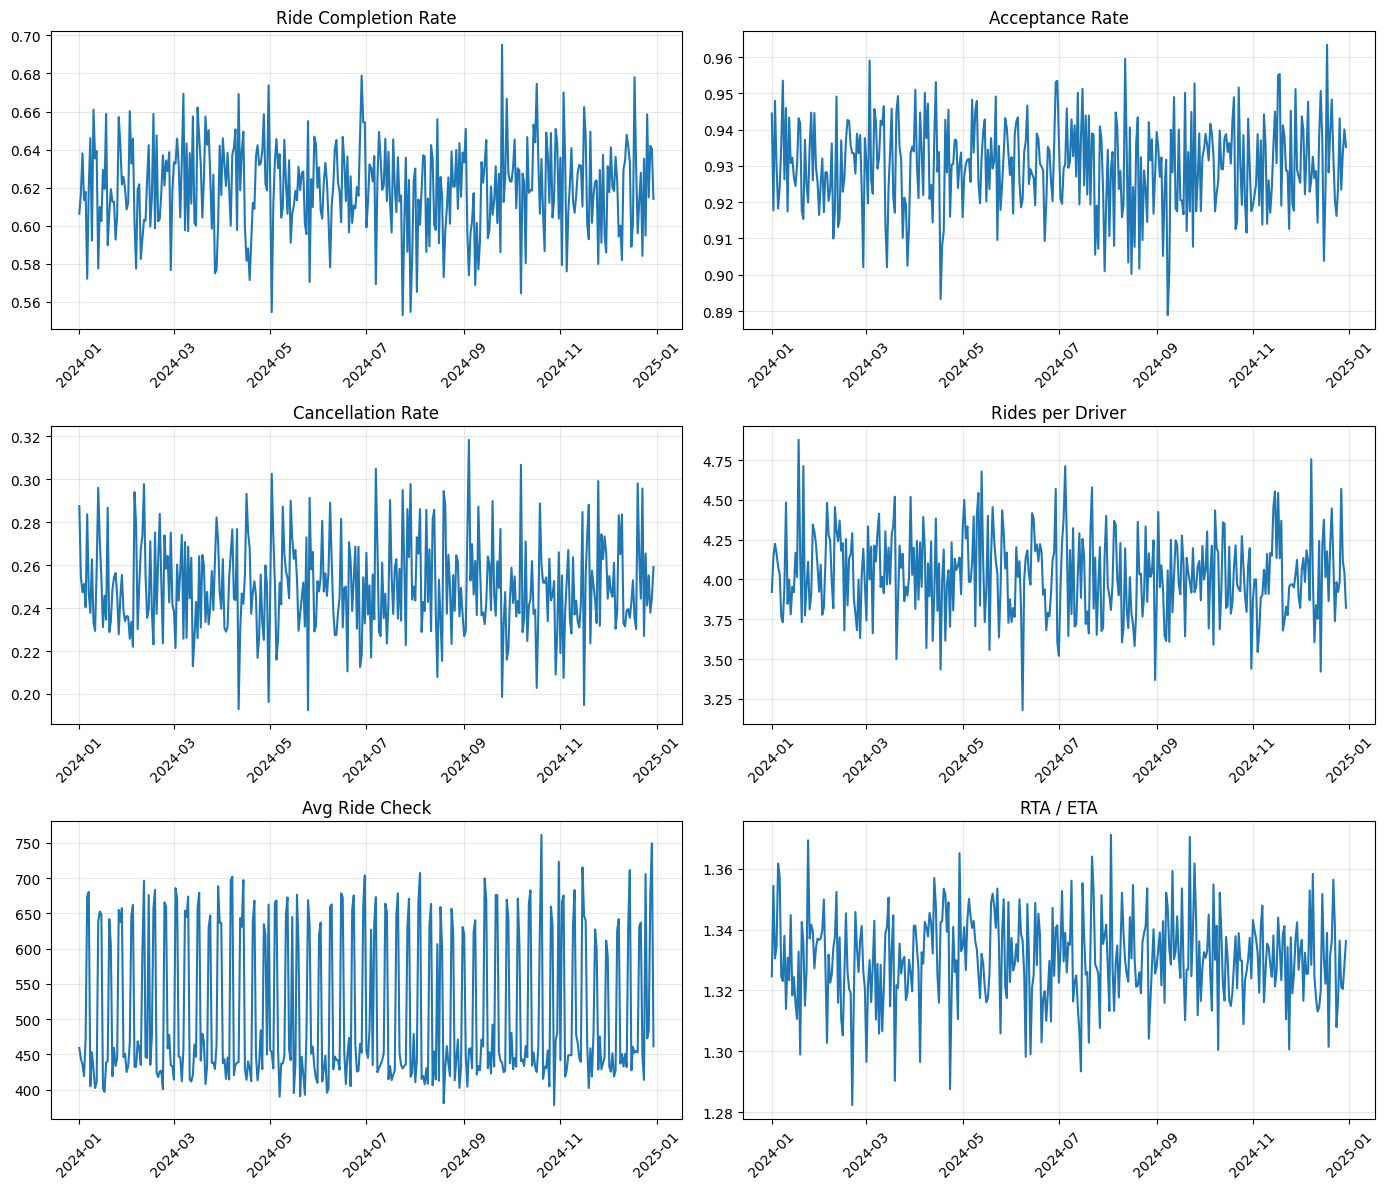

In [ ]:
df_rh['date'] = pd.to_datetime(df_rh['date'])

# флаги на уровне заказа
df_rh['is_completed'] = df_rh['order_status'] == 'Completed'
df_rh['is_accepted'] = df_rh['order_status'] != 'No Driver Found'
df_rh['is_cancelled'] = df_rh['order_status'].isin(['Cancelled by Driver', 'Cancelled by Customer'])
# отношение RTA к ETA считаем для каждого заказа, потом усредняем
df_rh['rta_eta_ratio'] = df_rh['RTA'] / df_rh['ETA']

daily_rh = df_rh.groupby('date').agg(
    completion_rate=('is_completed', 'mean'),
    acceptance_rate=('is_accepted', 'mean'),
    cancellation_rate=('is_cancelled', 'mean'),
    rta_eta_ratio=('rta_eta_ratio', 'mean')
)

# поездки на водителя и средний чек - по завершенным поездкам
completed_rides = df_rh[df_rh['order_status'] == 'Completed']
daily_rides = completed_rides.groupby('date').agg(
    rides=('order_uid', 'count'),
    drivers=('driver_id', 'nunique'),
    avg_check=('fare', 'mean')
)
daily_rh['rides_per_driver'] = daily_rides['rides'] / daily_rides['drivers']
daily_rh['avg_check'] = daily_rides['avg_check']

rh_metrics = {
    'completion_rate': 'Ride Completion Rate',
    'acceptance_rate': 'Acceptance Rate',
    'cancellation_rate': 'Cancellation Rate',
    'rides_per_driver': 'Rides per Driver',
    'avg_check': 'Avg Ride Check',
    'rta_eta_ratio': 'RTA / ETA'
}

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
for ax, metric in zip(axes.flatten(), rh_metrics):
    ax.plot(daily_rh.index, daily_rh[metric])
    ax.set_title(rh_metrics[metric])
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Что измеряет отношение RTA к ETA**

Метрика показывает, во сколько раз реальное время подачи машины больше того, что пообещали пассажиру. Значение 1 - водитель приехал ровно к прогнозу, больше 1 - опоздал, меньше 1 - приехал раньше.

У нас метрика стабильно держится около 1,33, то есть водители в среднем приезжают примерно на треть позже обещанного. Это метрика качества сервиса и точности прогноза ETA: чем ближе к 1, тем точнее обещание и тем меньше у пассажира поводов отменить заказ.

### Case Study. Запуск подкастов в стриминговом сервисе 🎧

**Легенда**  
Вы работаете продуктовым аналитиком в музыкальном стриминговом сервисе. Недавно в продукте запустился раздел с подкастами. Команда, отвечающая за запуск, хочет понять, стоит ли масштабировать и продвигать этот формат.

In [ ]:
df_music_logs = pd.read_parquet('data/hw_2_streaming_logs.pqt')
df_music_subs = pd.read_parquet('data/hw_2_streaming_subs.pqt')

In [ ]:
df_music_logs.head()

,datetime,uid,item_id,played_ratio_pct,track_length_seconds,content_type,is_first_date
0,2024-01-13 10:00:00,468300,7400764,100,225,music,0.0
1,2024-01-13 10:00:05,347600,3415205,100,250,music,0.0
2,2024-01-13 10:00:10,942900,6728180,1,270,music,0.0
3,2024-01-13 10:00:15,243500,5283544,100,195,music,0.0
4,2024-01-13 10:00:15,12700,8932363,100,245,music,0.0


In [ ]:
df_music_subs.head()

,uid,start_date,end_date
0,600,2024-08-08,NaT
1,700,2024-03-29,NaT
2,800,2024-06-13,NaT
3,1100,2024-11-19,NaT
4,1400,2024-12-01,NaT


Описание данных hw_2_streaming_logs:

- datetime — дата-время взаимодействия с контентом
- uid — уникальный идентификатор пользователя
- item_id — уникальный идентификатор трека/эпизода
- played_ratio_pct — процент от длительности, который был воспроизведен
- track_length_seconds – длина трека/эпизода в секундах
- content_type — тип контента: музыка или подкаст
- is_first_date — флаг, является ли эта дата первой для пользователя в продукте

Описание данных hw_2_streaming_subs:

- uid — уникальный идентификатор пользователя
- start_date — дата начала подписки
- end_date — дата окончания подписки

#### 3. Метрики роста  — 2 балла

Рассчитайте и визуализируйте:
- DAU, MAU, WAU;
- Количество новых премиум-подписчиков (за неделю и месяц);
- Проникновение подкастов — долю юзеров, послушавших подкаст хотя бы раз (за неделю и месяц).

Сделайте выводы:
- Есть ли выраженный тренд?
- Нет ли подозрений, что с раскаткой раздела что-то могло пойти не так (изменение тренда, выраженные ступеньки)?
- Как выглядит адопшен? Можно ли предположить наличие каких-то эффектов в пользовательском взаимодействии с новым разделом?

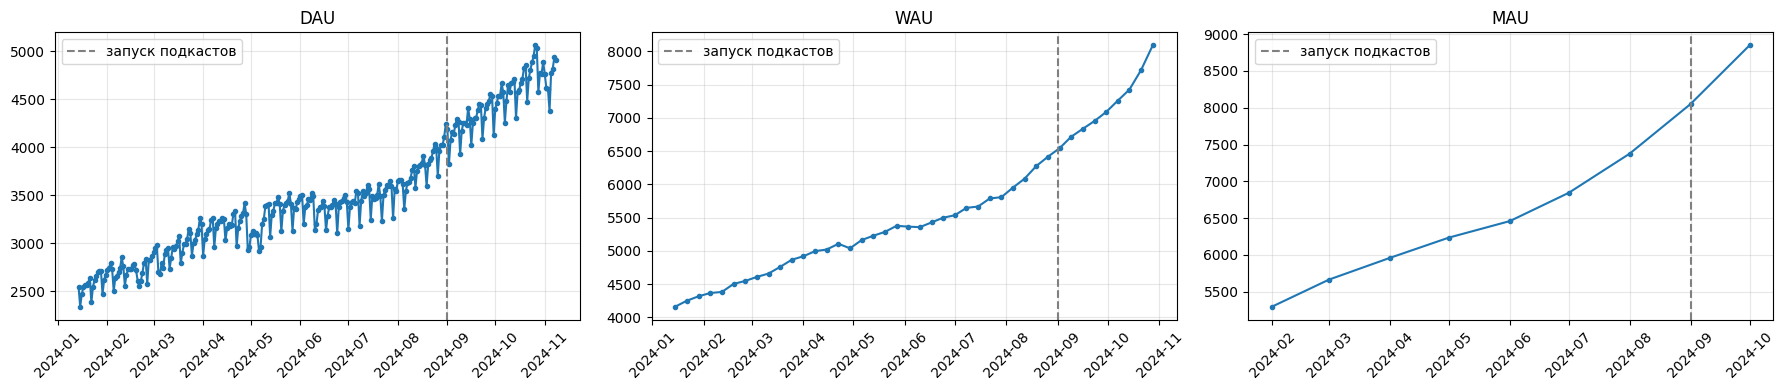

In [ ]:
df_music_logs['date'] = df_music_logs['datetime'].dt.normalize()
df_music_logs['week'] = df_music_logs['datetime'].dt.to_period('W').dt.start_time
df_music_logs['month'] = df_music_logs['datetime'].dt.to_period('M').dt.start_time

# логи начинаются в субботу 13.01.2024 (с 10 утра) и заканчиваются утром в субботу 09.11.2024,
# поэтому неполные первые и последние дни / недели / месяцы обрезаем
first_day, last_day = '2024-01-14', '2024-11-08'
first_week, last_week = '2024-01-15', '2024-10-28'
first_month, last_month = '2024-02-01', '2024-10-01'
launch_date = pd.Timestamp('2024-09-01')  # первое прослушивание подкаста в логах

# DAU, WAU, MAU
dau = df_music_logs.groupby('date')['uid'].nunique().loc[first_day:last_day]
wau = df_music_logs.groupby('week')['uid'].nunique().loc[first_week:last_week]
mau = df_music_logs.groupby('month')['uid'].nunique().loc[first_month:last_month]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, data, title in zip(axes, [dau, wau, mau], ['DAU', 'WAU', 'MAU']):
    ax.plot(data.index, data.values, marker='.')
    ax.axvline(launch_date, color='gray', linestyle='--', label='запуск подкастов')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

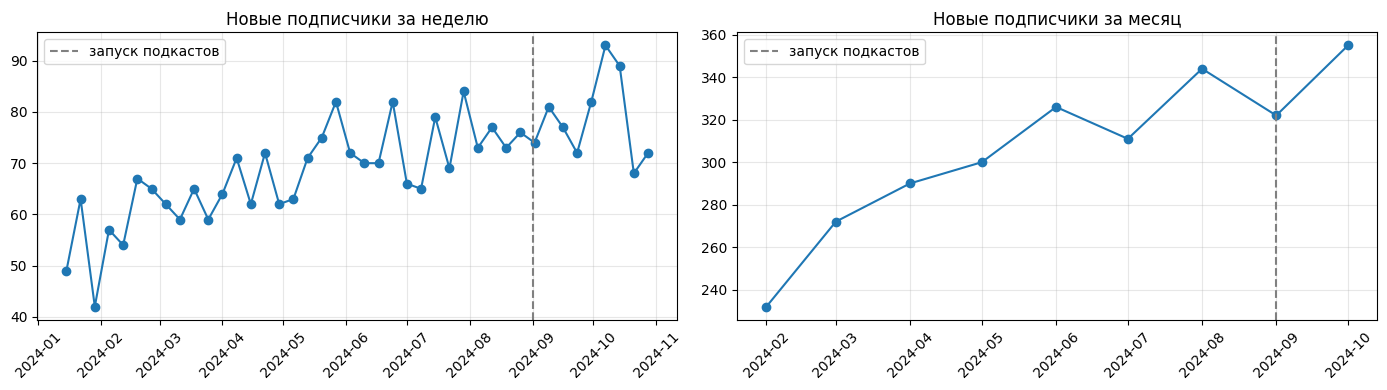

In [ ]:
# новые премиум-подписчики - по дате начала подписки
df_music_subs['start_week'] = df_music_subs['start_date'].dt.to_period('W').dt.start_time
df_music_subs['start_month'] = df_music_subs['start_date'].dt.to_period('M').dt.start_time

new_subs_week = df_music_subs.groupby('start_week')['uid'].count().loc[first_week:last_week]
new_subs_month = df_music_subs.groupby('start_month')['uid'].count().loc[first_month:last_month]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, data, title in zip(axes, [new_subs_week, new_subs_month], ['Новые подписчики за неделю', 'Новые подписчики за месяц']):
    ax.plot(data.index, data.values, marker='o')
    ax.axvline(launch_date, color='gray', linestyle='--', label='запуск подкастов')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

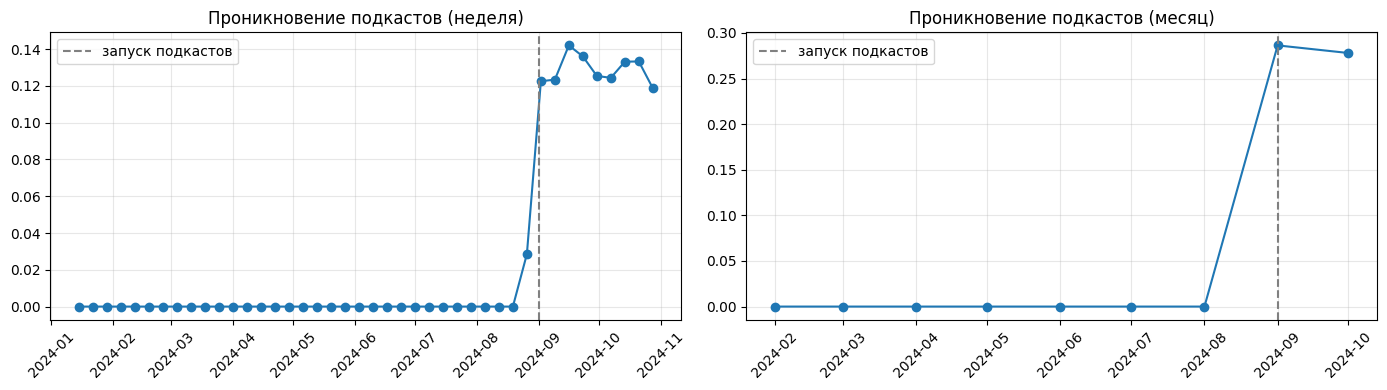

week
2024-09-02    0.123
2024-09-09    0.123
2024-09-16    0.142
2024-09-23    0.136
2024-09-30    0.125
2024-10-07    0.124
2024-10-14    0.133
2024-10-21    0.133
2024-10-28    0.119
Name: uid, dtype: float64


In [ ]:
# проникновение подкастов - доля активных за период юзеров, у которых был хотя бы один подкаст
podcast_users_week = df_music_logs[df_music_logs['content_type'] == 'podcast'].groupby('week')['uid'].nunique()
podcast_users_month = df_music_logs[df_music_logs['content_type'] == 'podcast'].groupby('month')['uid'].nunique()

penetration_week = (podcast_users_week / wau).fillna(0).loc[first_week:last_week]
penetration_month = (podcast_users_month / mau).fillna(0).loc[first_month:last_month]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, data, title in zip(axes, [penetration_week, penetration_month], ['Проникновение подкастов (неделя)', 'Проникновение подкастов (месяц)']):
    ax.plot(data.index, data.values, marker='o')
    ax.axvline(launch_date, color='gray', linestyle='--', label='запуск подкастов')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(penetration_week.loc[launch_date:].round(3))

**Выводы**

**Есть ли выраженный тренд?**
Да, аудитория растет весь год: DAU с ~2,5 тыс. в январе до ~4,8 тыс. в начале ноября, WAU с ~4,2 до ~8,1 тыс., MAU с ~5,3 до ~8,9 тыс. С июля рост заметно ускоряется. В DAU видна недельная сезонность (провалы по понедельникам) и просадка в начале мая (праздники). Новые премиум-подписчики тоже растут: с ~230 в феврале до ~355 в октябре, понедельно ряд шумный (40-90 в неделю).

**Нет ли подозрений, что с раскаткой что-то пошло не так?**
Явной ступеньки или слома тренда в момент запуска нет. Около 01.09 на DAU есть небольшой подъем, но он в пределах обычных колебаний, а ускорение роста WAU и MAU началось раньше, в июле-августе. Поэтому связывать рост аудитории с подкастами нельзя. Новые подписки после запуска тоже идут в рамках тренда (в сентябре даже немного меньше, чем в августе, в октябре - максимум). Отдельно стоит проверить данные: новые пользователи (`is_first_date = 1`) перестают появляться после 25.10, хотя WAU продолжает расти - похоже на особенность выгрузки, а не на эффект запуска.

**Как выглядит адопшен?**
Старт резкий: уже в первую полную неделю ~12% активных пользователей послушали подкаст, за сентябрь - ~29% MAU. Дальше доля не растет: пик ~14% на неделе 16.09, потом плато и небольшое снижение до ~12% к концу октября, месячная доля тоже чуть снизилась (~29% -> ~28%). Похоже на эффект новизны: в первые недели многие попробовали раздел из любопытства, дальше часть перестала. Разница между недельным (~13%) и месячным (~28%) проникновением говорит о том, что большинство слушает подкасты эпизодически, а не каждую неделю. В абсолютных числах слушателей подкастов становится больше, но только за счет роста всей аудитории.

#### 4. Метрики продукта (шаг 1)  — 2 балла

Рассчитайте и визуализируйте как для всех пользователей в совокупности, так и для сегментов пользователей в разрезе — сделали / не сделали взаимодействие с подкастами (грубо говоря разделяем юзеров на тех, кто слушает только музыку и тех, кто слушает еще и подкасты):
1. Среднее время прослушивания на пользователя.
2. Среднее число треков/эпизодов на пользователя (среднее число item_id). Посчитайте метрику, как от уникальных, так и от не уникальных item_id. Подумайте, что показывает каждая из них?
3. Долю премиум-подписчиков. Обратите внимание, что нам нужна активная подписка, если пользователь отписался в том же периоде, что подписался, мы больше не считаем подписку активной.

Рассчитайте и визуализируйте как по всем item_id, так и в разрезе типов контента:
- Долю дослушанных треков/эпизодов до конца. Обратите внимание, данная метрика уже не пользовательская.

Периоды — неделя и месяц. Неполные периоды нужно обрезать, если они мешают чтению графиков.   
Признак взаимодействия присвайвайте только для периода, когда оно действительно было.   
Для месячной динамики метрик по признаку взаимодействия с подкастами у вас получится всего 2 точки, такая визуализая тоже полезна, она сглаживает недельные колебания и помогает оценивать тренд в масштабе года.

Сделайте выводы:
- Есть ли выраженный тренд?
- Изменилась ли метрика после запуска подкастов?
- Отличается ли метрика сегмента, взаимодействовавшего с подкастами, от тех, кто слушал только музыку? (будьте аккуратны с выводами в этом пункте, мы не проверяем изменение на каузальность, поэтому не можем быть уверены где причина, а где следствие)
- Есть ли отличия между типами контента?

*За взаимодействие с подкастами давайте считать только прослушивание >= 30% или более 2х минут контента*

In [ ]:
# сколько секунд реально прослушано
df_music_logs['played_sec'] = df_music_logs['played_ratio_pct'] / 100 * df_music_logs['track_length_seconds']
# взаимодействие с подкастом: прослушано >= 30% эпизода или более 2 минут
df_music_logs['podcast_listen'] = (df_music_logs['content_type'] == 'podcast') & (
    (df_music_logs['played_ratio_pct'] >= 30) | (df_music_logs['played_sec'] > 120))
# трек / эпизод дослушан до конца
df_music_logs['is_finished'] = df_music_logs['played_ratio_pct'] >= 100

df_music_subs['end_week'] = df_music_subs['end_date'].dt.to_period('W').dt.start_time
df_music_subs['end_month'] = df_music_subs['end_date'].dt.to_period('M').dt.start_time


def get_users_table(period):
    # одна строка = пользователь в периоде
    users = df_music_logs.groupby([period, 'uid']).agg(
        listen_time=('played_sec', 'sum'),
        items=('item_id', 'count'),
        unique_items=('item_id', 'nunique'),
        podcast_flag=('podcast_listen', 'max')
    ).reset_index()
    users['listen_time'] = users['listen_time'] / 60  # в минутах

    # сегмент определяется только по этому периоду
    users['segment'] = 'only music'
    users.loc[users['podcast_flag'], 'segment'] = 'music + podcasts'

    # подписка активна в периоде, если началась не позже этого периода
    # и не закончилась в этом же периоде (или не закончилась вообще)
    users = users.merge(df_music_subs[['uid', 'start_' + period, 'end_' + period]], on='uid', how='left')
    users['is_premium'] = (users['start_' + period] <= users[period]) & (
        users['end_' + period].isna() | (users['end_' + period] > users[period]))
    return users


users_week = get_users_table('week')
users_week = users_week[(users_week['week'] >= first_week) & (users_week['week'] <= last_week)]
users_month = get_users_table('month')
users_month = users_month[(users_month['month'] >= first_month) & (users_month['month'] <= last_month)]

user_metrics = ['listen_time', 'items', 'unique_items', 'is_premium']

# все пользователи
all_week = users_week.groupby('week')[user_metrics].mean()
all_month = users_month.groupby('month')[user_metrics].mean()

# сегменты - только после запуска подкастов
seg_week = users_week[users_week['week'] >= launch_date].groupby(['week', 'segment'])[user_metrics].mean().reset_index()
seg_month = users_month[users_month['month'] >= launch_date].groupby(['month', 'segment'])[user_metrics].mean().reset_index()

# размер сегментов
print(users_week[users_week['week'] >= launch_date].groupby(['week', 'segment'])['uid'].count().unstack())
print(users_month[users_month['month'] >= launch_date].groupby(['month', 'segment'])['uid'].count().unstack())

segment     music + podcasts  only music
week                                    
2024-09-02               478        6067
2024-09-09               496        6222
2024-09-16               588        6249
2024-09-23               598        6356
2024-09-30               555        6534
2024-10-07               587        6673
2024-10-14               626        6801
2024-10-21               670        7050
2024-10-28               586        7505
segment     music + podcasts  only music
month                                   
2024-09-01              1390        6660
2024-10-01              1545        7301


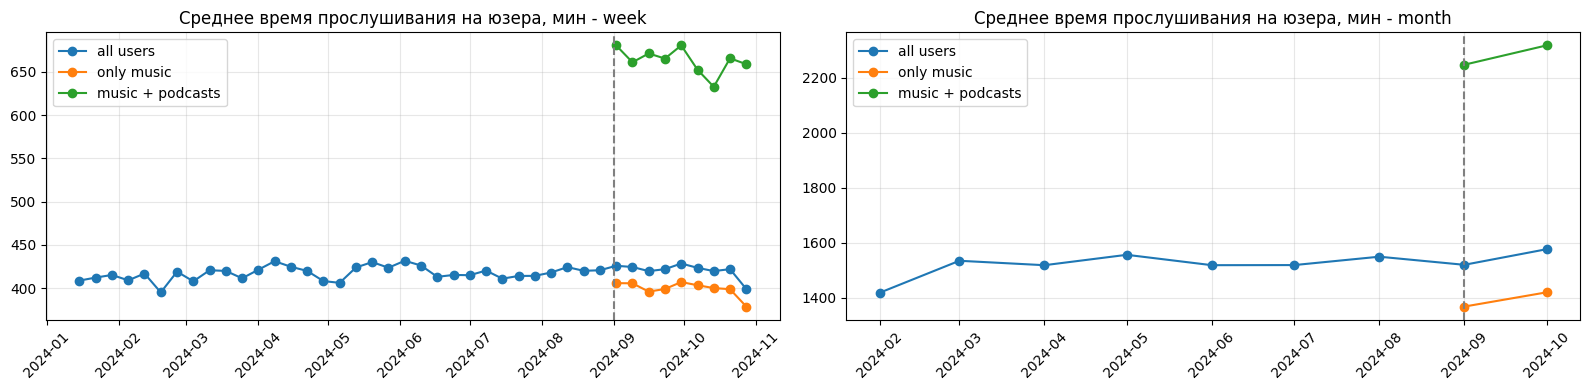

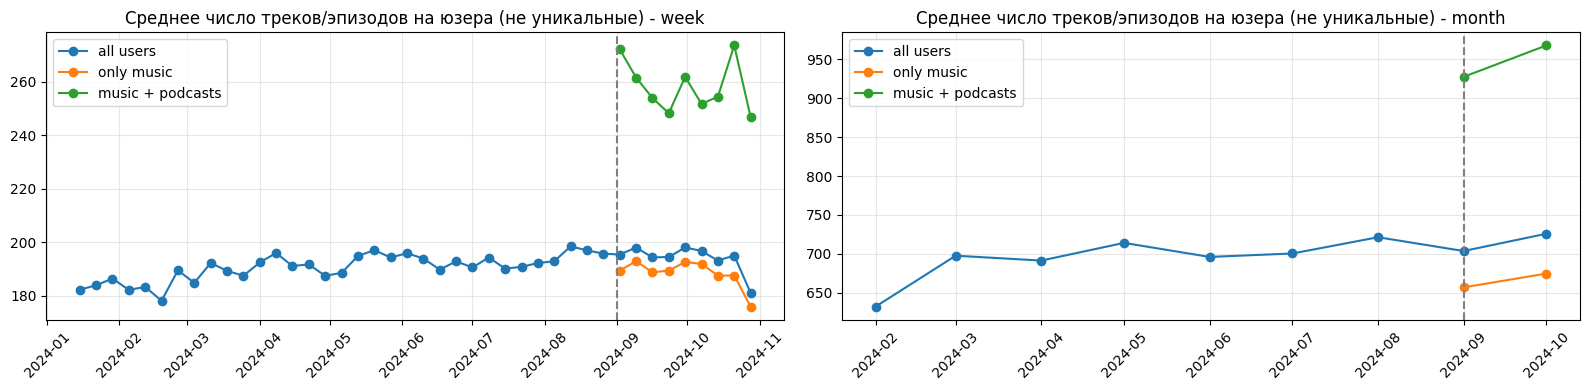

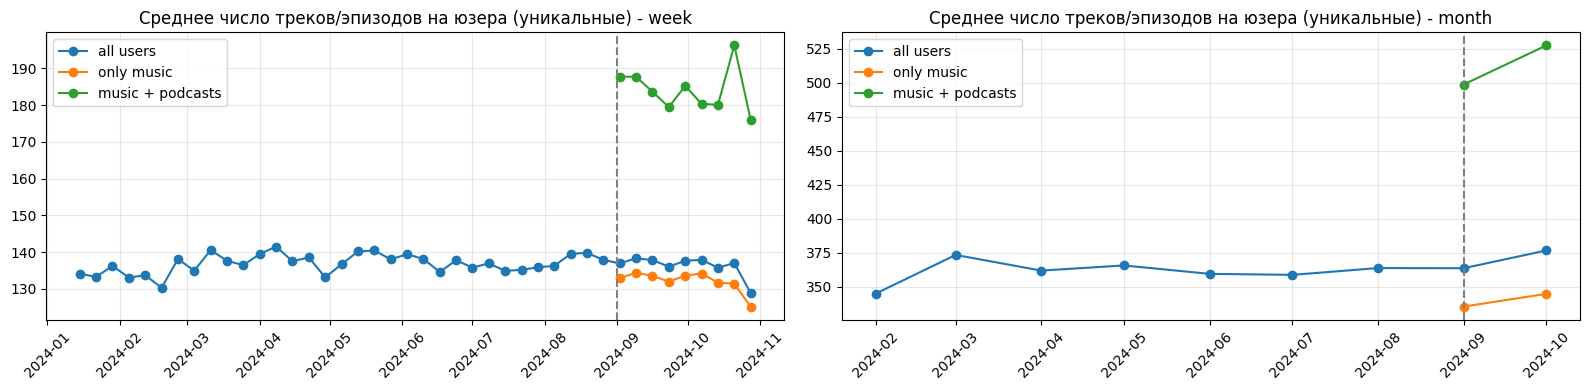

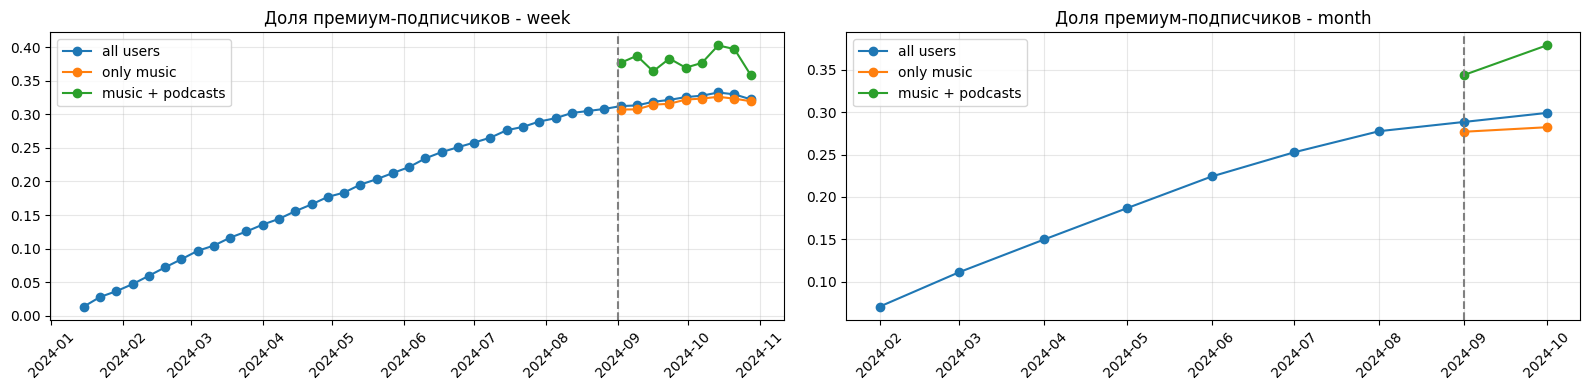

In [ ]:
titles = {
    'listen_time': 'Среднее время прослушивания на юзера, мин',
    'items': 'Среднее число треков/эпизодов на юзера (не уникальные)',
    'unique_items': 'Среднее число треков/эпизодов на юзера (уникальные)',
    'is_premium': 'Доля премиум-подписчиков'
}

for metric in titles:
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    for ax, all_data, seg_data, period in [(axes[0], all_week, seg_week, 'week'), (axes[1], all_month, seg_month, 'month')]:
        ax.plot(all_data.index, all_data[metric], marker='o', label='all users')
        for segment in ['only music', 'music + podcasts']:
            data = seg_data[seg_data['segment'] == segment]
            ax.plot(data[period], data[metric], marker='o', label=segment)
        ax.axvline(launch_date, color='gray', linestyle='--')
        ax.set_title(titles[metric] + ' - ' + period)
        ax.tick_params(axis='x', rotation=45)
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

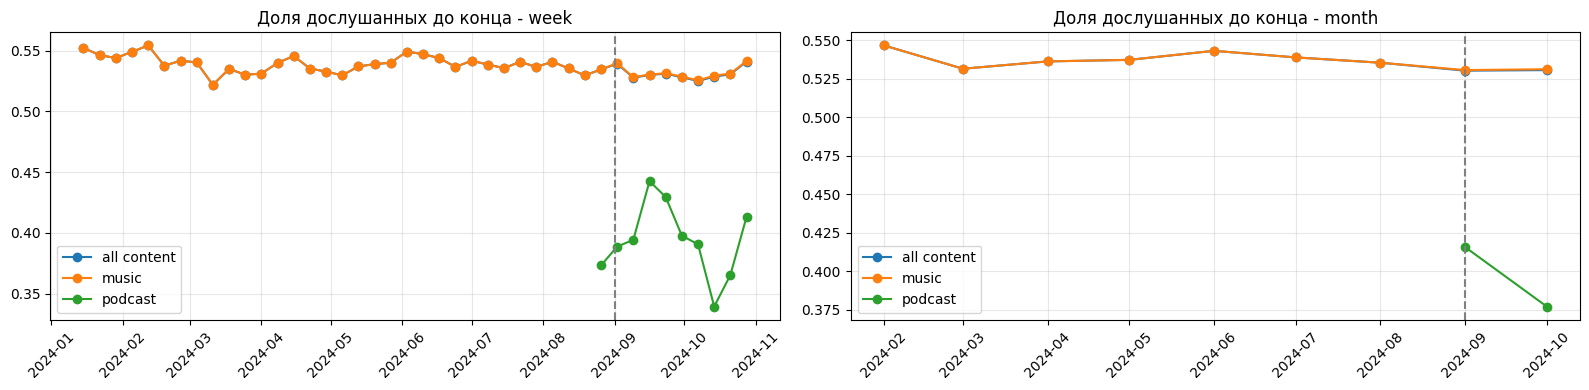

In [ ]:
# доля дослушанных до конца - на уровне прослушиваний (не пользователей)
finished_week = df_music_logs.groupby('week')['is_finished'].mean().loc[first_week:last_week]
finished_month = df_music_logs.groupby('month')['is_finished'].mean().loc[first_month:last_month]
finished_week_type = df_music_logs.groupby(['week', 'content_type'])['is_finished'].mean().unstack().loc[first_week:last_week]
finished_month_type = df_music_logs.groupby(['month', 'content_type'])['is_finished'].mean().unstack().loc[first_month:last_month]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, all_data, type_data, period in [(axes[0], finished_week, finished_week_type, 'week'), (axes[1], finished_month, finished_month_type, 'month')]:
    ax.plot(all_data.index, all_data.values, marker='o', label='all content')
    ax.plot(type_data.index, type_data['music'], marker='o', label='music')
    ax.plot(type_data.index, type_data['podcast'], marker='o', label='podcast')
    ax.axvline(launch_date, color='gray', linestyle='--')
    ax.set_title('Доля дослушанных до конца - ' + period)
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Выводы**

Что показывают две версии метрики по числу треков: неуникальные item_id - это общий объем потребления (сколько раз что-то включали, с повторами), уникальные - широта потребления (сколько разного контента пользователь открыл для себя). Их отношение ~1,4, то есть пользователи заметно часто переслушивают одно и то же.

**Есть ли выраженный тренд?**
- Время прослушивания и число треков на пользователя весь год почти не меняются (~410-430 минут и ~180-200 треков в неделю). В месячной разбивке февраль ниже из-за короткого месяца. В последнюю неделю (28.10) метрики немного просели - одновременно с резким ростом WAU, то есть пришло много менее активных пользователей.
- Доля премиум-подписчиков растет с ~1% в январе до ~32% в конце октября, но рост замедляется. Важно: в таблице подписок нет подписок, оформленных до 13.01, поэтому в начале года доля занижена, и часть роста - это просто накопление данных.
- Доля дослушанных музыкальных треков стабильна, ~53-55%.

**Изменилась ли метрика после запуска подкастов?**
По всем пользователям заметных изменений нет: время, число треков, доля дослушанных и доля премиума продолжают прежнюю динамику. Сегмент с подкастами - всего ~8% недельной аудитории, поэтому на общие средние он влияет слабо.

**Отличается ли сегмент с подкастами?**
Да, заметно: ~650-680 минут в неделю против ~400 у "только музыка", ~250-270 треков/эпизодов против ~190, уникальных ~180-190 против ~133, доля премиума ~36-40% против ~31-32%. Но это не значит, что подкасты причина: скорее в новый раздел в первую очередь приходят самые вовлеченные пользователи и подписчики. Кроме того, эпизоды длинные (10-40 минут), так что время прослушивания растет у слушателей подкастов почти автоматически. Сегмент "только музыка" ниже общей линии тоже ожидаемо - из него просто ушли самые активные. Вывода о каннибализации музыки отсюда сделать нельзя.

**Есть ли отличия между типами контента?**
Подкасты дослушивают реже: ~34-44% в неделю (месяц: ~42% в сентябре и ~38% в октябре) против ~53% у музыки. Это ожидаемо - эпизод в среднем примерно в 7 раз длиннее трека. Снижение от сентября к октябрю согласуется с эффектом новизны. Линия "all content" совпадает с музыкой, потому что подкасты - очень малая доля всех прослушиваний.

#### 5. Метрики продукта (шаг 2)  — 2 балла

Рассчитайте и визуализируйте:
1) D1, D7, D30 retention по всем пользователям. Когорты агрегируйте по неделям т.к. из-за низкого числа новичков на дневном разрезе визуализации слишком шумные.
2) D30 retention для сегментов пользователей в разрезе — сделали / не сделали взаимодействие с подкастами на промежутке до 30 дня. Когорты агрегируйте по неделям.
3) D7 retention для сегментов пользователей в разрезе — сделали / не сделали взаимодействие с подкастами на промежутке до 7 дня. Когорты агрегируйте по месяцам.

Для наглядности будет полезно нарисовать на одном графике как посегментную, так и общую динамику (для этого можете достроить D7 retention для всех пользователей с помесячной агрегацией).

Сделайте выводы:
- Есть ли выраженный тренд?
- Изменилась ли метрика после запуска подкастов?
- Отличается ли метрика сегмента, взаимодействовавшего с подкастами, от тех, кто слушал только музыку? (будьте аккуратны с выводами в этом пункте, мы не проверяем изменение на каузальность, поэтому не можем быть уверены где причина, а где следствие)

*За взаимодействие с подкастами давайте считать только прослушивание >= 30% или более 2х минут контента*

In [ ]:
# последний полный день в логах
last_full_date = pd.Timestamp('2024-11-08')

# дата первого захода новичков
first_dates = df_music_logs[df_music_logs['is_first_date'] == 1].groupby('uid')['date'].min().reset_index()
first_dates.columns = ['uid', 'first_date']

# дни активности новичков и номер дня от первого захода
activity = df_music_logs[['uid', 'date']].drop_duplicates()
activity = activity.merge(first_dates, on='uid')
activity['day_n'] = (activity['date'] - activity['first_date']).dt.days

# дни, когда было взаимодействие с подкастом (>= 30% или > 2 минут)
podcast_days = df_music_logs[df_music_logs['podcast_listen']][['uid', 'date']].drop_duplicates()
podcast_days = podcast_days.merge(first_dates, on='uid')
podcast_days['day_n'] = (podcast_days['date'] - podcast_days['first_date']).dt.days

cohorts = first_dates.copy()
cohorts['cohort_week'] = cohorts['first_date'].dt.to_period('W').dt.start_time
cohorts['cohort_month'] = cohorts['first_date'].dt.to_period('M').dt.start_time

# вернулся ли юзер ровно на 1 / 7 / 30 день
for n in [1, 7, 30]:
    returned_users = activity[activity['day_n'] == n]['uid']
    cohorts['d' + str(n)] = cohorts['uid'].isin(returned_users)

# сегмент по взаимодействию с подкастами до 7 / до 30 дня (дни 0..6 и 0..29)
cohorts['segment_d7'] = 'only music'
cohorts.loc[cohorts['uid'].isin(podcast_days[podcast_days['day_n'] < 7]['uid']), 'segment_d7'] = 'music + podcasts'
cohorts['segment_d30'] = 'only music'
cohorts.loc[cohorts['uid'].isin(podcast_days[podcast_days['day_n'] < 30]['uid']), 'segment_d30'] = 'music + podcasts'

# берем только тех, у кого день n уже наступил в данных
observed_1 = cohorts[cohorts['first_date'] + timedelta(days=1) <= last_full_date]
observed_7 = cohorts[cohorts['first_date'] + timedelta(days=7) <= last_full_date]
observed_30 = cohorts[cohorts['first_date'] + timedelta(days=30) <= last_full_date]

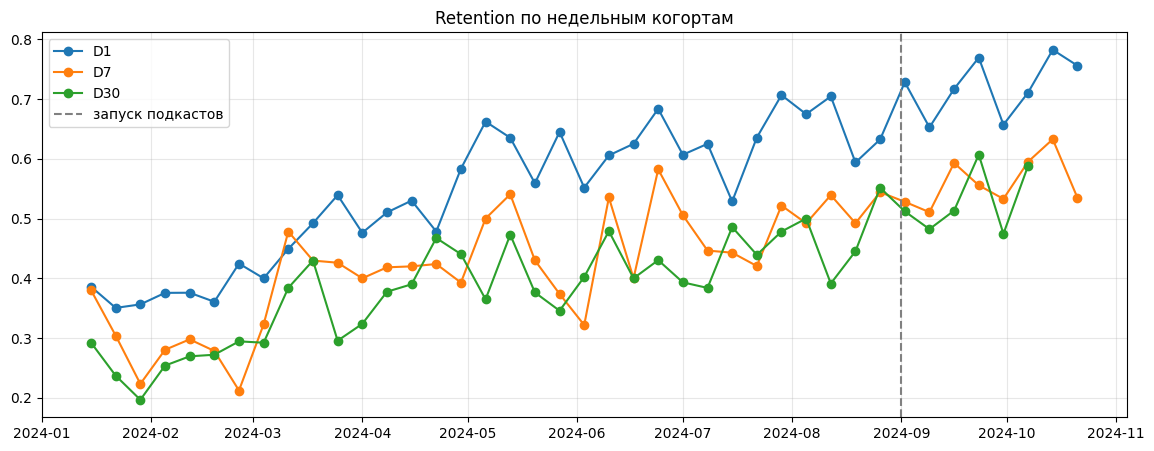

In [ ]:
# 1) D1, D7, D30 retention по всем, недельные когорты
retention_week = pd.DataFrame({
    'D1': observed_1.groupby('cohort_week')['d1'].mean(),
    'D7': observed_7.groupby('cohort_week')['d7'].mean(),
    'D30': observed_30.groupby('cohort_week')['d30'].mean()
}).loc[first_week:last_week]

plt.figure(figsize=(14, 5))
for col in ['D1', 'D7', 'D30']:
    plt.plot(retention_week.index, retention_week[col], marker='o', label=col)
plt.axvline(launch_date, color='gray', linestyle='--', label='запуск подкастов')
plt.title('Retention по недельным когортам')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

segment_d30  music + podcasts  only music
cohort_week                              
2024-09-02                 29          96
2024-09-09                 27         114
2024-09-16                 27          86
2024-09-23                 29          88
2024-09-30                 34         103
2024-10-07                 14          37


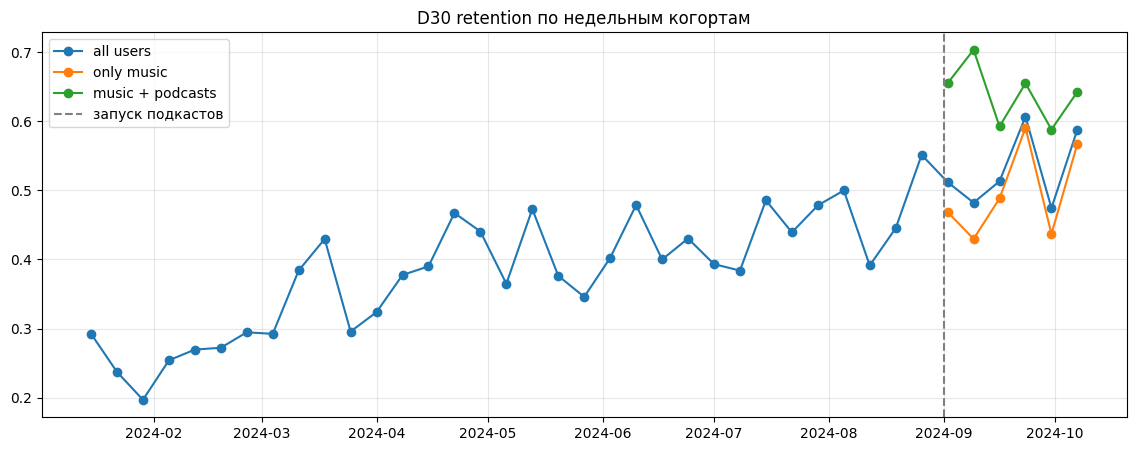

In [ ]:
# 2) D30 retention по сегментам, недельные когорты (когорты после запуска подкастов)
observed_30_after = observed_30[observed_30['cohort_week'] >= launch_date]
d30_segments = observed_30_after.groupby(['cohort_week', 'segment_d30'])['d30'].mean().unstack()
print(observed_30_after.groupby(['cohort_week', 'segment_d30'])['uid'].count().unstack())

plt.figure(figsize=(14, 5))
plt.plot(retention_week.index, retention_week['D30'], marker='o', label='all users')
for segment in ['only music', 'music + podcasts']:
    plt.plot(d30_segments.index, d30_segments[segment], marker='o', label=segment)
plt.axvline(launch_date, color='gray', linestyle='--', label='запуск подкастов')
plt.title('D30 retention по недельным когортам')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

segment_d7    music + podcasts  only music
cohort_month                              
2024-09-01                  74         458
2024-10-01                  64         407


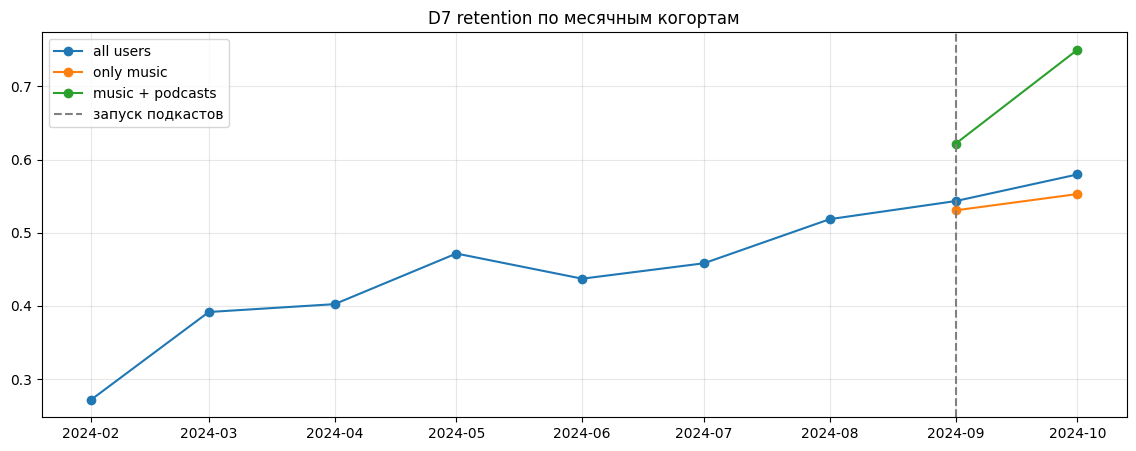

In [ ]:
# 3) D7 retention по сегментам, месячные когорты + общий D7 по месяцам
d7_month = observed_7.groupby('cohort_month')['d7'].mean().loc[first_month:last_month]

observed_7_after = observed_7[observed_7['cohort_month'] >= launch_date]
d7_segments = observed_7_after.groupby(['cohort_month', 'segment_d7'])['d7'].mean().unstack()
print(observed_7_after.groupby(['cohort_month', 'segment_d7'])['uid'].count().unstack())

plt.figure(figsize=(14, 5))
plt.plot(d7_month.index, d7_month.values, marker='o', label='all users')
for segment in ['only music', 'music + podcasts']:
    plt.plot(d7_segments.index, d7_segments[segment], marker='o', label=segment)
plt.axvline(launch_date, color='gray', linestyle='--', label='запуск подкастов')
plt.title('D7 retention по месячным когортам')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Выводы**

Когорты новичков маленькие (~110 человек в неделю), поэтому недельные графики шумные. Последние когорты обрезаны: D30 можно посчитать только для тех, кто пришел не позже 09.10, а новые пользователи в данных заканчиваются 25.10.

**Есть ли выраженный тренд?**
Да, retention растет весь год. D1 - с ~0,35-0,40 в январе-феврале до ~0,70-0,78 в октябре, D7 - с ~0,2-0,3 до ~0,55-0,6, D30 - с ~0,2-0,3 до ~0,5-0,6. Месячный D7 вырос с ~0,27 (февраль) до ~0,58 (октябрь).

**Изменилась ли метрика после запуска подкастов?**
Слома тренда нет: после запуска retention продолжает расти примерно тем же темпом, что и раньше (месячный D7: август ~0,52, сентябрь ~0,54, октябрь ~0,58). Рост начался задолго до подкастов, поэтому приписать его запуску нельзя.

**Отличается ли сегмент с подкастами?**
Да: D30 у тех, кто слушал подкасты в первые 30 дней, ~0,59-0,70 против ~0,43-0,59 у "только музыка"; D7 по месячным когортам - 0,62 против 0,53 в сентябре и 0,75 против 0,55 в октябре. Но выводы нужно делать осторожно:
- выборка маленькая - 14-34 человека с подкастами в недельной когорте, 64-74 в месячной;
- сегмент смещен по построению: чтобы послушать подкаст в первые 7 / 30 дней, пользователь должен быть активен в эти дни, поэтому в сегмент чаще попадают и так вовлеченные пользователи, у которых retention выше. Причину и следствие здесь разделить нельзя.

#### 6. Приоритизация метрик  — 2 балла

Составьте список всех метрик, которые были рассчитаны выше (не забудьте, что показатель, рассчитанный в разрезе сегмента — это отдельная метрика). Для простоты давайте ориентироваться только на недельную агрегацию.

1. Присвойте метрикам приоритеты P0-P3 по принципу (в этом пункте стройте приоритизацию на уровне всей компании):
   -  P0 — бизнес результат;
   -  P1 — метрики продукта, напрямую аффектящие бизнес-результат (retention, product as a habit);
   -  P2 — метрики, отражающие взаимодействие пользователя с продуктом (user experience, user engagement) / таргет-метрики отдельных команд продукта;
   -  P3 — метрики стримов / опыт пользователя в рамках работы отдельных команд.
2. Пересоберите приоритеты только для команды подкастов, если цель развития подкастов — рост пользователей с подпиской. Обратите внимание, что вам не нужно отказываться от метрик, рассчитанных по всем пользователям (без сегментов) или для сегмента Music (полезно понимать, не каннибализируем ли мы основной тип контента). Скорее всего приоритеты изменятся только для посегментных метрик.
4. Представьте, что цель внедрения подкастов поменялась — теперь команда в первую очередь хочет задрайвить вовлеченность в продукт. Пересоберите приоритеты при необходимости (в данном пункте могут измениться приоритеты для метрик, рассчитанных по всем пользователям).

Для каждого из пунктов дайте краткое обоснование, почему вы присвоили приоритеты именно так.

Список метрик (недельная агрегация). DAU и MAU не выписываем отдельно - это та же метрика активной аудитории, что и WAU, в другой гранулярности. D7 retention по сегментам мы считали по месяцам, его приоритет совпадает с D30 по сегментам.

| # | Метрика | 1. Вся компания | 2. Подкасты, цель - подписки | 3. Подкасты, цель - вовлеченность |
|---|---|---|---|---|
| 1 | Новые премиум-подписчики за неделю | P0 | P0 | P0 |
| 2 | Доля премиум-подписчиков (все) | P0 | P0 | P0 |
| 3 | Доля премиум-подписчиков (music + podcasts) | P3 | **P0** | P2 |
| 4 | Доля премиум-подписчиков (only music) | P3 | **P1** | P2 |
| 5 | WAU | P1 | P1 | P1 |
| 6 | D1 retention (все) | P1 | P1 | P1 |
| 7 | D7 retention (все) | P1 | P1 | P1 |
| 8 | D30 retention (все) | P1 | P1 | P1 |
| 9 | D30 retention (music + podcasts) | P3 | **P1** | **P1** |
| 10 | D30 retention (only music) | P3 | **P2** | **P2** |
| 11 | Проникновение подкастов | P2 | **P1** | **P1** |
| 12 | Среднее время прослушивания (все) | P2 | P2 | **P1** |
| 13 | Среднее время прослушивания (music + podcasts) | P3 | **P2** | **P2** |
| 14 | Среднее время прослушивания (only music) | P3 | P3 | **P2** |
| 15 | Среднее число треков, неуникальные (все) | P2 | P2 | **P1** |
| 16 | Среднее число треков, неуникальные (music + podcasts) | P3 | **P2** | **P2** |
| 17 | Среднее число треков, неуникальные (only music) | P3 | P3 | **P2** |
| 18 | Среднее число треков, уникальные (все) | P2 | P2 | P2 |
| 19 | Среднее число треков, уникальные (music + podcasts) | P3 | P3 | P3 |
| 20 | Среднее число треков, уникальные (only music) | P3 | P3 | P3 |
| 21 | Доля дослушанных (весь контент) | P2 | P2 | P2 |
| 22 | Доля дослушанных (музыка) | P3 | P3 | P3 |
| 23 | Доля дослушанных (подкасты) | P3 | **P2** | **P2** |

**1. Приоритизация для всей компании**
- P0 - новые подписчики и доля премиума: подписка - это деньги, то есть прямой бизнес-результат.
- P1 - WAU и retention по всем: пользователь, который возвращается и формирует привычку, со временем покупает подписку и дольше ее не отменяет, то есть эти метрики напрямую влияют на P0.
- P2 - вовлеченность по всем пользователям (время, число треков, доля дослушанных) и проникновение подкастов (таргет команды подкастов): показывают, насколько людям нравится продукт, но влияют на деньги опосредованно.
- P3 - все метрики в разрезе сегментов и типов контента: это детализация, которая нужна отдельным командам, чтобы понимать свой участок, но для компании в целом они вторичны.

**2. Команда подкастов, цель - рост пользователей с подпиской**

Метрики по всем пользователям сохраняют приоритеты, меняются в основном посегментные.
- P0 - к общим бизнес-метрикам добавляется доля премиума в сегменте music + podcasts: это прямой вклад команды в цель.
- P1 - проникновение подкастов (главный рычаг: чем больше людей в сегменте, где доля премиума выше, тем больше подписок) и D30 retention сегмента подкастов (удержанный слушатель чаще доходит до подписки). Доля премиума у only music - guardrail на P1: нельзя, чтобы рост подписок в одном сегменте шел за счет падения в другом.
- P2 - вовлеченность слушателей подкастов (время, число эпизодов, доля дослушанных подкастов) и D30 у only music: показывают качество контента и опыт, который ведет к подписке, плюс контроль, что мы не вредим музыке.
- P3 - остальные посегментные метрики музыки и широта потребления.

**3. Команда подкастов, цель - вовлеченность в продукт**
- P0 не меняется: бизнес-результат компании остается главным, команда не должна его ухудшать. А вот доля премиума в сегменте подкастов уходит в P2 - она больше не цель команды, а контрольная метрика.
- P1 - таргетом становится вовлеченность всех пользователей: среднее время прослушивания и число прослушиваний по всем поднимаются в P1 вместе с WAU и retention. Проникновение подкастов и D30 сегмента подкастов остаются в P1 как основные рычаги вовлечения.
- P2 - время и число прослушиваний отдельно по сегментам: по music + podcasts видно, растет ли вовлеченность благодаря подкастам, а по only music - не каннибализируем ли мы музыку (если время просто перетекает из музыки в подкасты, общая вовлеченность не вырастет). Сюда же доля дослушанных подкастов и D30 у only music.
- P3 - широта потребления по сегментам и доля дослушанных музыки, на цель команды они почти не влияют.